In [2]:
import os
import json
import numpy as np
import xarray as xr
import proplot as pplt
import warnings
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')
pplt.rc.update({'figure.dpi':100})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR = CONFIGS['filepaths']['splits']
MODELSDIR = CONFIGS['filepaths']['models']
PREDSDIR  = CONFIGS['filepaths']['predictions']
MODELS    = CONFIGS['experiments']
SPLIT     = 'valid'

In [4]:
def get_r2(ytrue,ypred):
    ssres = ((ytrue-ypred)**2).sum(skipna=True)
    sstot = ((ytrue-ytrue.mean(skipna=True))**2).sum(skipna=True)
    return float(1-ssres/sstot)

def _mainnn_nparams(nfeatures):
    '''Count parameters in the MainNN backbone (256->128->64->32->1 with biases).'''
    return nfeatures*256+256 + 256*128+128 + 128*64+64 + 64*32+32 + 32*1+1

def compute_nn_nparams(kind,nfieldvars,nlevs,nlocalvars):
    '''Compute number of trainable parameters for each NN model kind.'''
    if kind=='baseline':
        return _mainnn_nparams(nfieldvars*nlevs+nlocalvars)
    elif kind=='nonparametric':
        kernel = nfieldvars*nlevs
        return kernel+_mainnn_nparams(nfieldvars+nlocalvars)
    elif kind=='lfconditioned':
        kernel = (1*16+16)+(16*32+32)+(32*nfieldvars*nlevs+nfieldvars*nlevs)
        return kernel+_mainnn_nparams(nfieldvars+nlocalvars)
    elif kind=='lfthreshold':
        kernel = 2*nfieldvars*nlevs
        return kernel+_mainnn_nparams(nfieldvars+nlocalvars)
    elif kind=='parametric':
        kernel = 2*nfieldvars
        return kernel+_mainnn_nparams(nfieldvars+nlocalvars)
    else:
        raise ValueError(f'Unknown model kind: {kind}')

def get_nlevs(fieldvars,splitsdir):
    '''Determine number of vertical levels from the training split.'''
    with xr.open_dataset(os.path.join(splitsdir,'norm_train.h5'),engine='h5netcdf') as ds:
        return ds.sizes['sig'] if 'sig' in ds[fieldvars[0]].dims else 1

def pareto_front(records):
    '''Extract Pareto-optimal points (minimize nparams, maximize R2).'''
    ordered = sorted(records,key=lambda r:r['nparams'])
    front   = []
    best_r2 = -np.inf
    for r in ordered:
        if r['r2']>best_r2:
            front.append(r)
            best_r2 = r['r2']
    return front

In [5]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    truetp = ds.tp.load()

records     = []
nlevs_cache = {}

# POD models
for name,runconfig in MODELS['pod']['runs'].items():
    filepath = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
    if not os.path.exists(filepath):
        continue
    with xr.open_dataset(filepath) as ds:
        predtp = ds.tp.load()
    ytrue,ypred = xr.align(truetp,predtp,join='inner')
    r2 = get_r2(ytrue,ypred)
    npzpath = os.path.join(MODELSDIR,'pod',f'{name}.npz')
    with np.load(npzpath) as data:
        nparams = int(data['nparams'])
    records.append({'name':name,'kind':'pod','r2':r2,'nparams':nparams})

# NN models
for name,runconfig in MODELS['nn']['runs'].items():
    filepath = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
    if not os.path.exists(filepath):
        continue
    with xr.open_dataset(filepath) as ds:
        predtp = ds.tp.load()
    ytrue,ypred = xr.align(truetp,predtp,join='inner')
    if 'seed' in ypred.dims:
        ypred = ypred.mean('seed')
    r2 = get_r2(ytrue,ypred)
    fieldvars = runconfig['fieldvars']
    localvars = runconfig.get('localvars',[])
    key = tuple(fieldvars)
    if key not in nlevs_cache:
        nlevs_cache[key] = get_nlevs(fieldvars,SPLITSDIR)
    nlevs   = nlevs_cache[key]
    nparams = compute_nn_nparams(runconfig['kind'],len(fieldvars),nlevs,len(localvars))
    records.append({'name':name,'kind':runconfig['kind'],'r2':r2,'nparams':nparams})

print(f'Found {len(records)} models with predictions')
for r in sorted(records,key=lambda x:x['nparams']):
    print(f"  {r['name']:55s}  nparams={r['nparams']:>8,}  R\u00b2={r['r2']:.4f}")

Found 12 models with predictions
  pod_bl                                                   nparams=       2  R²=0.0927
  pod_bl_lf                                                nparams=       4  R²=0.1490
  baseline_bl                                              nparams=  43,777  R²=0.2844
  baseline_cape                                            nparams=  43,777  R²=0.0448
  baseline_subsat                                          nparams=  43,777  R²=0.2772
  baseline_rh                                              nparams=  46,337  R²=0.3935
  baseline_thetae                                          nparams=  46,337  R²=0.2477
  baseline_thetaestar                                      nparams=  46,337  R²=0.2242
  baseline_rh_lf                                           nparams=  46,593  R²=0.4260
  baseline_rh_lhf                                          nparams=  46,593  R²=0.4307
  baseline_rh_shf                                          nparams=  46,593  R²=0.4432
  baseline

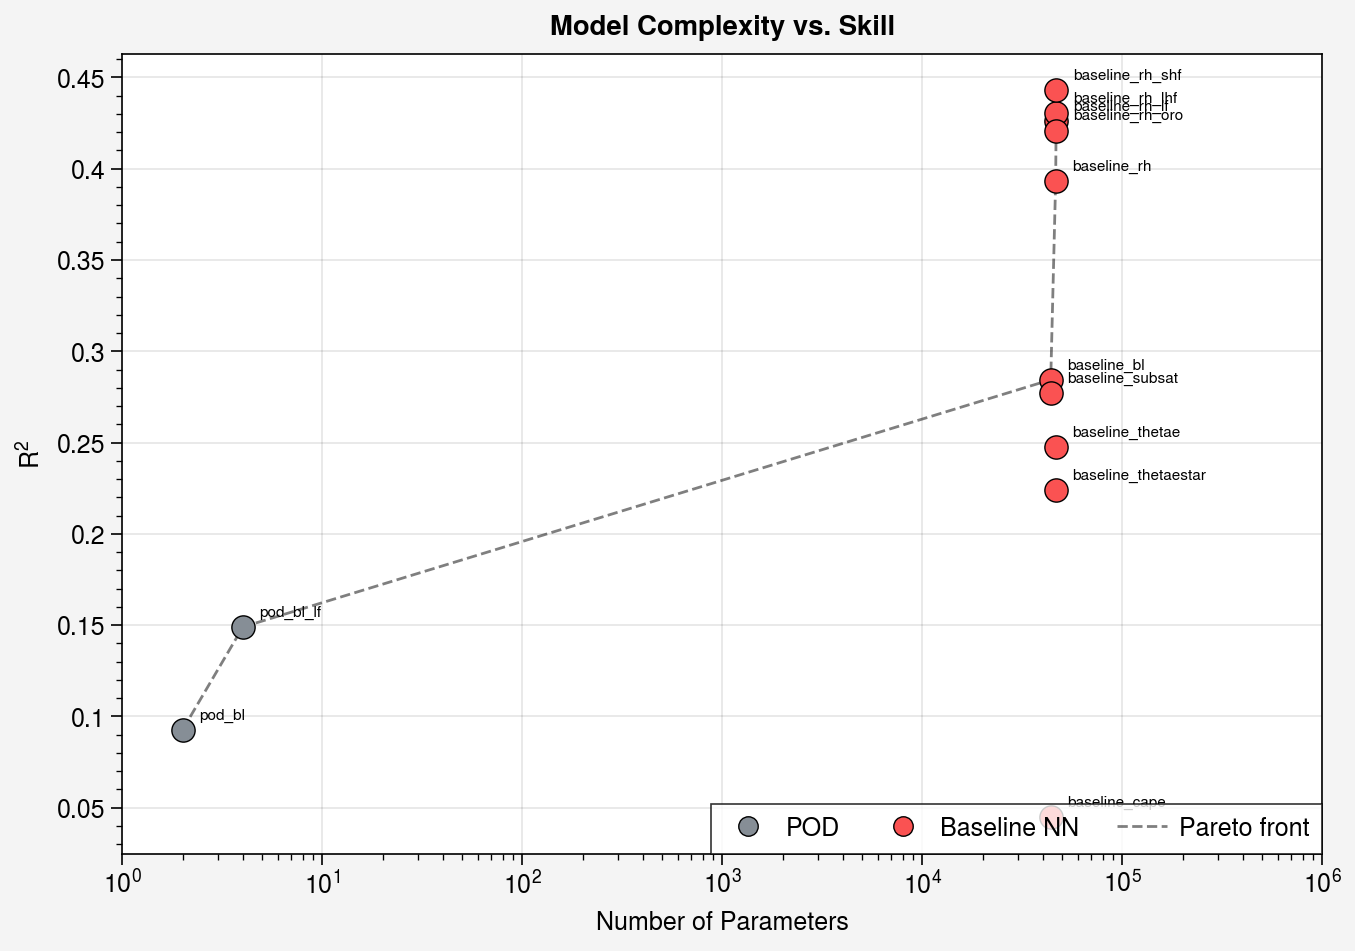

In [8]:
KIND_STYLE = {
    'pod':            {'color':'gray6',   'label':'POD'},
    'baseline':       {'color':'red6',    'label':'Baseline NN'},
    'nonparametric':  {'color':'blue6',   'label':'Nonparametric Kernel'},
    'lfconditioned':  {'color':'yellow6', 'label':'LF-Conditioned Kernel'},
    'lfthreshold':    {'color':'green6',  'label':'LF-Threshold Kernel'},
    'parametric':     {'color':'violet6', 'label':'Parametric Kernel'},
}

fig,ax = pplt.subplots(refwidth=6,refheight=4)
for r in records:
    style = KIND_STYLE.get(r['kind'],{'color':'gray6'})
    ax.scatter(r['nparams'],r['r2'],color=style['color'],s=70,zorder=3,
              edgecolor='k',linewidth=0.5)
    ax.annotate(r['name'],(r['nparams'],r['r2']),
               textcoords='offset points',xytext=(6,4),fontsize=5.5)

front = pareto_front(records)
if len(front)>1:
    ax.plot([r['nparams'] for r in front],[r['r2'] for r in front],
            color='k',linewidth=1,linestyle='--',alpha=0.5,zorder=2,
            label='Pareto front')

seen = set()
handles = []
for r in records:
    kind = r['kind']
    if kind not in seen:
        seen.add(kind)
        style = KIND_STYLE.get(kind,{'color':'gray6','label':kind})
        handles.append(Line2D([],[],marker='o',color='none',markerfacecolor=style['color'],
                              markeredgecolor='k',markeredgewidth=0.5,markersize=7,
                              label=style['label']))
if len(front)>1:
    handles.append(Line2D([],[],color='k',linewidth=1,linestyle='--',alpha=0.5,
                          label='Pareto front'))
ax.legend(handles=handles,loc='lower right',fontsize=7)

ax.format(suptitle='Model Complexity vs. Skill',
          xlabel='Number of Parameters',ylabel='R$^2$',
          xscale='log',xformatter='log',grid=True,xlim=(1e0,1e6))
pplt.show()